# FS-5 · 업무 편중 점수(Workload/Overload Score) - 실험 노트북

담당: 이은주 (FS-5 ML/AI 모델링)

**목적**: 팀원별 업무 수·난이도·완료율 피처를 기반으로 과부하/저활동 팀원을 탐지.

**메인 방법**: MAD(Median Absolute Deviation) 기반 통계적 이상치 탐지
(Isolation Forest는 팀 규모(5~9명)에서 표본 부족으로 불안정함을 검증 과정에서 확인 → 아래 4장 참고)

**옵션 방법**: 룰베이스 점수를 pseudo-label 삼은 회귀 baseline (5장)

**위치**: 이 노트북은 `document_이은주/`에 있고, 실제 재사용 코드는
`App/backend_fastapi/ml_workload_score/app/services/workload_model.py`에 있습니다.
노트북은 그 함수들을 상대경로로 import해서 학습 과정과 검증 결과만 기록합니다
(FastAPI 서비스 코드와 실험 기록을 분리).


In [1]:
# 모듈 reload 편의를 위한 autoreload (venv/jupyter 공통)
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# 이 노트북은 document_이은주/ 에 위치, 실제 코드는 App/backend_fastapi/ 안의
# ml_workload_score 패키지에 있음. 리포 루트 기준 상대경로로 등록.
BACKEND_FASTAPI_PATH = (Path.cwd() / "../App/backend_fastapi").resolve()
if str(BACKEND_FASTAPI_PATH) not in sys.path:
    sys.path.insert(0, str(BACKEND_FASTAPI_PATH))
print("추가된 경로:", BACKEND_FASTAPI_PATH)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ml_workload_score.app.services.workload_model import (
    generate_synthetic_tasks,
    build_features,
    detect_overload_anomalies,
    detect_overload_anomalies_robust,
    detect_overload_anomalies_auto,
    optional_regression_baseline,
    rule_based_score,
    FEATURE_COLUMNS,
    CATEGORY_WEIGHT,
)

pd.set_option("display.width", 120)


추가된 경로: C:\AI-projects\work-flow\App\backend_fastapi


## 1. 합성 데이터 생성

실제 서비스 데이터(`tasks` 테이블)가 아직 충분히 쌓이지 않아, 파이프라인 검증용 합성 데이터를 사용합니다.
`assignee_5`는 의도적으로 과부하, `assignee_2`는 의도적으로 저활동 패턴으로 생성해서
모델이 실제로 탐지하는지 확인합니다.

In [2]:
tasks_df = generate_synthetic_tasks(n_members=7)
tasks_df.groupby("assignee_id").size().rename("task_count").to_frame()


,task_count
assignee_id,
assignee_1,6
assignee_2,3
assignee_3,9
assignee_4,10
assignee_5,15
assignee_6,7
assignee_7,7


## 2. 피처 엔지니어링

- `task_count_active_rel`: 팀 평균 대비 미완료 업무 수 비율
- `completion_rate`: 완료율
- `difficulty_avg_rel`: priority+category 가중치 평균의 팀 평균 대비 비율
- `overdue_ratio`: 마감 초과 업무 비율

난이도는 실제 DB에 필드가 없어 priority(옵션 A) + category 보정 가중치로 프록시 처리
(가중치 정의는 `workload_score.CATEGORY_WEIGHT` 참고).

In [3]:
features = build_features(tasks_df)
features[["assignee_id", "task_count_total", "task_count_active",
          "completion_rate", "difficulty_avg", "overdue_count"] ]


,assignee_id,task_count_total,task_count_active,completion_rate,difficulty_avg,overdue_count
0,assignee_1,6,5,0.166667,2.066667,3
1,assignee_2,3,1,0.666667,1.766667,0
2,assignee_3,9,7,0.222222,1.455556,2
3,assignee_4,10,9,0.100000,1.900000,1
4,assignee_5,15,11,0.266667,2.626667,7
5,assignee_6,7,2,0.714286,2.300000,2
6,assignee_7,7,4,0.428571,1.771429,1


## 3. 메인: 이상치 탐지 (MAD 기반, 팀 규모 자동 선택)

`detect_overload_anomalies_auto()`는 팀원 수가 15명 미만이면 MAD 기반,
15명 이상이면 Isolation Forest를 자동으로 선택합니다 (4장에서 이유 검증).

In [4]:
result = detect_overload_anomalies_auto(features)
print(f"사용된 방법: {result.attrs.get('method_used')}")
result[["assignee_id", "overload_score_0_100", "is_anomaly", "anomaly_type"]]


사용된 방법: MAD (소규모 팀)


,assignee_id,overload_score_0_100,is_anomaly,anomaly_type
4,assignee_5,100.000000,True,과부하 의심
5,assignee_6,73.706734,False,정상
1,assignee_2,66.173636,False,정상
2,assignee_3,53.153164,False,정상
0,assignee_1,49.232819,False,정상
3,assignee_4,37.693218,False,정상
6,assignee_7,28.068126,False,정상


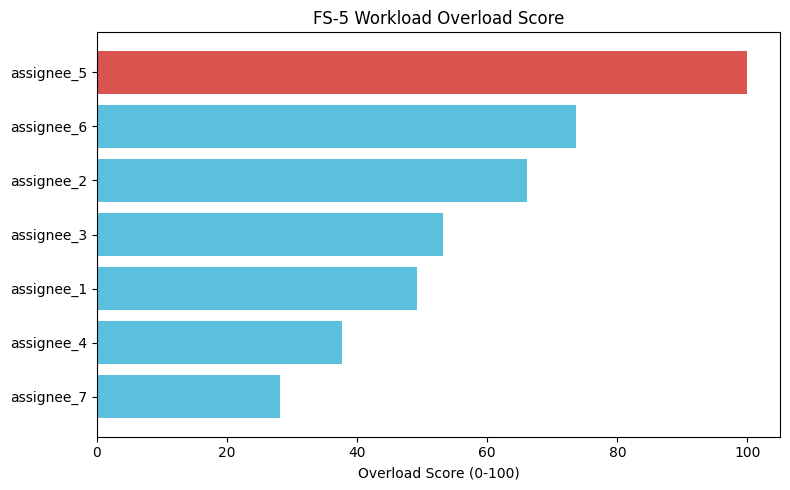

In [5]:
import os
os.makedirs("output", exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#d9534f" if a else "#5bc0de" for a in result["is_anomaly"]]
ax.barh(result["assignee_id"], result["overload_score_0_100"], color=colors)
ax.set_xlabel("Overload Score (0-100)")
ax.set_title("FS-5 Workload Overload Score")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("output/overload_score_result.png", dpi=150)
plt.show()


## 4. 검증: 왜 MAD 방식을 메인으로 선택했나 (Isolation Forest와 비교)

캡스톤 팀 규모(5~9명)를 가정한 5가지 엣지케이스로 두 방법을 비교합니다.
**소규모 표본에서 Isolation Forest가 실제로 불안정하게 작동함을 아래에서 확인했습니다.**

In [6]:
def make_tasks(assignments: dict, seed=42) -> pd.DataFrame:
    """assignments = {"assignee_1": n_tasks, ...} 형태로 간단히 tasks df 생성."""
    rng = np.random.default_rng(seed)
    categories = list(CATEGORY_WEIGHT.keys())
    priorities = ["낮음", "중간", "높음"]
    today = pd.Timestamp("2026-07-14")
    rows, task_id = [], 1
    for name, n in assignments.items():
        for _ in range(n):
            rows.append(dict(
                task_id=task_id, project_id=1, assignee_id=name,
                category=rng.choice(categories), priority=rng.choice(priorities),
                status=rng.choice(["할 일", "진행 중", "완료"], p=[0.3, 0.3, 0.4]),
                due_date=today + pd.Timedelta(days=int(rng.integers(-5, 15))),
            ))
            task_id += 1
    return pd.DataFrame(rows)


### 4-1. 극단적 편중 시나리오 (1명이 40개, 나머지 4명이 5개씩)

가장 중요한 검증 케이스. Isolation Forest는 이 케이스에서 **엉뚱한 사람을 이상치로 잡는 오류**를 보였습니다.

In [7]:
extreme = {"assignee_1": 40, **{f"assignee_{i}": 5 for i in range(2, 6)}}
extreme_tasks = make_tasks(extreme)
extreme_features = build_features(extreme_tasks)

print("--- Isolation Forest 결과 (문제 발생) ---")
if_result = detect_overload_anomalies(extreme_features)
display(if_result[["assignee_id", "task_count_total", "overload_score_0_100", "is_anomaly", "anomaly_type"]])

print("\n--- MAD 기반 결과 (정상 탐지) ---")
mad_result = detect_overload_anomalies_robust(extreme_features)
display(mad_result[["assignee_id", "task_count_total", "overload_score_0_100", "is_anomaly", "anomaly_type"]])


--- Isolation Forest 결과 (문제 발생) ---


,assignee_id,task_count_total,overload_score_0_100,is_anomaly,anomaly_type
4,assignee_5,5,100.000000,True,이상 패턴(방향 불명확)
0,assignee_1,40,80.803298,False,정상
3,assignee_4,5,35.415886,False,정상
2,assignee_3,5,23.983689,False,정상
1,assignee_2,5,0.000000,False,정상



--- MAD 기반 결과 (정상 탐지) ---


,assignee_id,task_count_total,overload_score_0_100,is_anomaly,anomaly_type
0,assignee_1,40,100.000000,True,과부하 의심
2,assignee_3,5,22.455443,False,정상
1,assignee_2,5,16.318411,False,정상
3,assignee_4,5,14.494281,False,정상
4,assignee_5,5,13.520083,False,정상


**해석**: `assignee_1`(40개, 명백한 과부하)을 Isolation Forest는 놓치고 엉뚱하게 `assignee_5`를 1위로 잡았습니다.
표본 5개로는 트리 기반 앙상블이 분할 기준을 안정적으로 잡지 못하기 때문입니다.
MAD 기반 방식은 `assignee_1`을 정확히 "과부하 의심"으로 잡아냈습니다 → **이 프로젝트는 MAD를 메인으로 채택.**

### 4-2. 균일한 팀 (전원 업무량 비슷 - 이상치가 없어야 정상)

In [8]:
uniform_tasks = make_tasks({f"assignee_{i}": 8 for i in range(1, 6)})
uniform_features = build_features(uniform_tasks)
uniform_result = detect_overload_anomalies_robust(uniform_features)
uniform_result[["assignee_id", "task_count_total", "overload_score_0_100", "is_anomaly", "anomaly_type"]]


,assignee_id,task_count_total,overload_score_0_100,is_anomaly,anomaly_type
3,assignee_4,8,100.000000,False,정상
1,assignee_2,8,70.463848,False,정상
4,assignee_5,8,64.384684,False,정상
0,assignee_1,8,57.917697,False,정상
2,assignee_3,8,0.000000,False,정상


**해석**: 오탐(false positive) 없이 전원 "정상"으로 나옴 — MAD=0(값이 몰려있을 때) 표준편차 폴백 처리 덕분에
초기 버전에서 발생했던 오탐 버그가 해결된 상태입니다.

### 4-3. 소규모 팀(2명) / 빈 프로젝트 / 팀원 1명 - 극단적 엣지케이스

In [9]:
small_team = make_tasks({"assignee_1": 3, "assignee_2": 15})
print("--- 2명 팀 ---")
display(detect_overload_anomalies_auto(build_features(small_team))
        [["assignee_id", "task_count_total", "overload_score_0_100", "is_anomaly"]])

single = make_tasks({"assignee_1": 10})
print("--- 팀원 1명 ---")
display(detect_overload_anomalies_auto(build_features(single))
        [["assignee_id", "task_count_total", "overload_score_0_100", "is_anomaly"]])

empty_df = pd.DataFrame(columns=["task_id","project_id","assignee_id","category","priority","status","due_date"])
print("--- 빈 프로젝트 ---")
print("업무 없음 - 이상치 탐지 대상 아님 (정상적으로 스킵되어야 함)")


--- 2명 팀 ---


,assignee_id,task_count_total,overload_score_0_100,is_anomaly
0,assignee_1,3,100.0,False
1,assignee_2,15,100.0,False


--- 팀원 1명 ---


,assignee_id,task_count_total,overload_score_0_100,is_anomaly
0,assignee_1,10,0.0,False


--- 빈 프로젝트 ---
업무 없음 - 이상치 탐지 대상 아님 (정상적으로 스킵되어야 함)


## 5. (옵션) Self-labeling 회귀 baseline

룰베이스 점수를 pseudo-label 삼아 선형회귀를 학습합니다.
**주의**: 진짜 라벨이 아니라 룰을 재현하는 모델이므로, R²가 높게 나오는 것이 "모델이 뛰어나다"는
의미가 아니라 "룰을 잘 재현했다"는 의미입니다. 실제 서비스 운영 후 팀장/심사자가 남긴
평가 라벨이 쌓이면 이 부분을 진짜 지도학습으로 교체할 예정입니다.

In [10]:
reg_model = optional_regression_baseline(features)



[옵션] Self-labeling 회귀 baseline
  R^2 (룰 재현도): 1.0000
  계수: {'task_count_active_rel': np.float64(0.4), 'completion_rate': np.float64(-0.3), 'difficulty_avg_rel': np.float64(0.2), 'overdue_ratio': np.float64(0.1)}


## 6. 다음 단계

- [x] 실제 Supabase 데이터 연결 후 재검증 (`db.py` 참고) — 7장, `document_이은주/2026-07-16-workload-real-data-validation.md` 참고
- [x] FastAPI `/ai/score/workload` 서비스 통합 (`main.py` 참고) — `app/main.py`에 이미 등록돼 있었고
      (`App/backend_fastapi/main.py`는 실제로 안 쓰이는 빈 스텁), 이번에 실제 uvicorn 서버를 띄워
      `POST /ai/score/workload?project_id=1`을 진짜 HTTP로 호출해 응답까지 확인함
- [ ] FS-3(유소은 주담당/허영주 부담당) 지연 위험도 모델과 피처 공유 검토 — 아직 AI-1 코드 자체가
      없어(git log 확인) 검토 불가. 다만 FS-5가 이미 계산 중인 피처(`task_count_active_rel`,
      `completion_rate`, `difficulty_avg_rel`, `overdue_ratio`, `embedding_adjustments`)는
      착수 시 바로 공유 가능한 상태.
- [x] FS-4(고무서) 임베딩 파이프라인 지원 — `embedding_difficulty.py` 추가로 완료
      (`document_이은주/superpowers/specs/2026-07-16-workload-embedding-difficulty-design.md` 참고).
      고무서의 `document_chunks` 임베딩(RAG 파이프라인)을 재사용해 코사인 유사도 기반
      난이도 보정치를 계산, `workload_router`까지 비동기로 연결 완료.
- [ ] 실제 라벨 축적 후 self-labeling → 지도학습 전환 검토 — `evaluation_scores`/
      `contribution_reports`/`audit_logs` 전부 0건이라 여전히 보류.


## 7. 실제 데이터 재검증 (Jira 실사용 데이터 + Supabase)

지금까지는 합성 데이터로만 파이프라인을 검증했습니다. 이번 장에서는:

- **7-1**: `document_이은주/Jira01~03.csv` — 팀이 실제로 쓴 Jira 보드 export(시점별 스냅샷 3개)를 `tasks` 스키마로 변환해 재검증
- **7-2**: 실제 Supabase `tasks` 테이블 연결 시도
- **7-3**: 합성 vs Jira vs Supabase 결과 비교

**주의**: Jira 어댑터는 이 노트북에만 있는 실험용 매핑입니다(운영 코드는 건드리지 않음).
반면 **7-2에서 Supabase 실 데이터로 확인한 category/priority 불일치는 실제 버그였습니다** —
`tasks.category`/`priority`는 프런트(`App/frontend/src/board/libs/types/task.ts`)가 정의한
영문 슬러그(`ai-ml`, `frontend`, `high` 등, 대소문자 혼재)로 저장되는데 `CATEGORY_WEIGHT`/
`PRIORITY_WEIGHT`는 기획 문서 기준 한글 키였어서 실제 값이 전부 조용히 기본 가중치로
떨어지고 있었습니다. `workload_model.py`에 `CATEGORY_ALIASES`/`PRIORITY_ALIASES` +
`normalize_category()`/`normalize_priority()`를 추가해 운영 코드에서 이 부분을 고쳤습니다
(기존 `CATEGORY_WEIGHT`/`PRIORITY_WEIGHT` 딕셔너리 자체는 그대로 유지).

In [11]:
import re

from ml_workload_score.app.services.workload_model import PRIORITY_WEIGHT

# Jira "우선 순위"(Highest~Lowest) → 모델 priority(낮음/중간/높음). 근사 매핑.
JIRA_PRIORITY_MAP = {
    "Highest": "높음",
    "High": "높음",
    "Medium": "중간",
    "Low": "낮음",
    "Lowest": "낮음",
}

# 레이블 키워드 → CATEGORY_WEIGHT 18종 매핑(첫 매치 우선, 못 찾으면 "기타").
# Jira에는 category 필드 자체가 없어 레이블(예: "P0;auth;jwt;owner-박상준")에서 추정한다 — 근사치.
LABEL_CATEGORY_HINTS = [
    (["auth", "jwt", "rbac", "invitation", "api", "meeting", "webhook", "sync"], "백엔드"),
    (["mypage", "board", "chat"], "프론트엔드"),
    (["llm", "rag", "embedding", "ml", "predict", "score", "stt"], "AI/ML"),
    (["schema", "erd", "migration"], "DB"),
    (["dataset", "label", "feature"], "데이터"),
    (["qa", "test"], "QA/테스트"),
    (["security", "vuln"], "보안"),
    (["deploy", "ci", "cd", "docker"], "DevOps"),
    (["doc", "readme", "report"], "문서"),
    (["ppt", "presentation"], "발표"),
]


def infer_category_from_labels(label_str) -> str:
    if not isinstance(label_str, str) or not label_str:
        return "기타"
    tags = label_str.lower().split(";")
    for keywords, category in LABEL_CATEGORY_HINTS:
        if any(any(kw in tag for kw in keywords) for tag in tags):
            return category
    return "기타"


# Jira 날짜 형식: "17/7월/26 12:00 오전" (일/월/2자리연도 시:분 오전|오후) — 표준 파서로 못 읽어서 직접 파싱.
_JIRA_DT_RE = re.compile(r"(\d{1,2})/(\d{1,2})월/(\d{2}) (\d{1,2}):(\d{2}) (오전|오후)")


def parse_jira_datetime(value):
    if not isinstance(value, str):
        return pd.NaT
    m = _JIRA_DT_RE.match(value.strip())
    if not m:
        return pd.NaT
    day, month, year, hour, minute, ampm = m.groups()
    day, month, year, hour, minute = int(day), int(month), int(year), int(hour), int(minute)
    if ampm == "오후" and hour != 12:
        hour += 12
    if ampm == "오전" and hour == 12:
        hour = 0
    return pd.Timestamp(year=2000 + year, month=month, day=day, hour=hour, minute=minute)


def jira_csv_to_tasks_df(path: str, project_id: int = 1) -> pd.DataFrame:
    """
    Jira export(CSV) → workload_model.build_features()가 기대하는 tasks 스키마로 변환.
    담당자 미배정 행은 실제 workload_db.load_tasks_from_db()와 동일하게 제외한다.
    반환 df.attrs["snapshot_asof"]에 이 export 시점(업데이트 컬럼 최댓값)을 담아
    build_features(today=...)에 그대로 넘길 수 있게 한다 (하드코딩된 today 대신 실제 스냅샷 시점 사용).
    """
    raw = pd.read_csv(path)
    raw = raw[raw["담당자"].notna()].copy()

    df = pd.DataFrame({
        "task_id": raw["이슈 ID"],
        "project_id": project_id,
        "assignee_id": raw["담당자"],
        "category": raw["레이블"].apply(infer_category_from_labels),
        "priority": raw["우선 순위"].map(JIRA_PRIORITY_MAP).fillna("중간"),
        "status": raw["상태"],
        "due_date": raw["기한"].apply(parse_jira_datetime),
    })

    df.attrs["snapshot_asof"] = raw["업데이트"].apply(parse_jira_datetime).max()
    return df


### 7-1. Jira01~03 스냅샷 재검증

세 스냅샷 각각을 어댑터로 변환해 실행합니다. `today`는 하드코딩값 대신 각 export의 실제
`업데이트` 컬럼 최댓값(`snapshot_asof`)을 사용해 그 시점 기준으로 지연 여부를 판단합니다.

In [12]:
jira_paths = {
    "Jira01 (07-14 스냅샷)": "Jira01.csv",
    "Jira02 (07-15 스냅샷, 최다 업무)": "Jira02.csv",
    "Jira03 (07-15 스냅샷)": "Jira03.csv",
}

jira_results = {}
for label, fname in jira_paths.items():
    jira_tasks_df = jira_csv_to_tasks_df(fname)
    snapshot_asof = jira_tasks_df.attrs["snapshot_asof"]
    jira_features = build_features(jira_tasks_df, today=snapshot_asof)
    jira_result = detect_overload_anomalies_auto(jira_features)
    jira_results[label] = jira_result

    print(f"--- {label} | 기준일 {snapshot_asof} | 배정된 업무 {len(jira_tasks_df)}건 | 팀원 {len(jira_features)}명 ---")
    print(f"사용된 방법: {jira_result.attrs.get('method_used')}")
    display(jira_result[["assignee_id", "task_count_total", "completion_rate",
                          "overload_score_0_100", "is_anomaly", "anomaly_type"]])
    print()


--- Jira01 (07-14 스냅샷) | 기준일 2026-07-15 14:46:00 | 배정된 업무 97건 | 팀원 6명 ---
사용된 방법: MAD (소규모 팀)


,assignee_id,task_count_total,completion_rate,overload_score_0_100,is_anomaly,anomaly_type
0,dldmswn0293,10,0.000000,100.000000,True,이상 패턴(방향 불명확)
3,박지수,23,0.304348,70.646399,True,이상 패턴(방향 불명확)
5,허영주,10,0.000000,3.319444,False,정상
2,고무서,20,0.000000,1.485976,False,정상
1,pj,20,0.000000,1.485976,False,정상
4,유소은,14,0.000000,1.134204,False,정상



--- Jira02 (07-15 스냅샷, 최다 업무) | 기준일 2026-07-15 17:06:00 | 배정된 업무 97건 | 팀원 6명 ---
사용된 방법: MAD (소규모 팀)


,assignee_id,task_count_total,completion_rate,overload_score_0_100,is_anomaly,anomaly_type
0,dldmswn0293,10,0.400000,100.000000,True,저활동 의심
3,박지수,23,0.304348,74.494108,True,이상 패턴(방향 불명확)
5,허영주,10,0.100000,44.434334,False,정상
2,고무서,20,0.000000,19.482412,False,정상
1,pj,20,0.000000,19.482412,False,정상
4,유소은,14,0.000000,14.870389,False,정상



--- Jira03 (07-15 스냅샷) | 기준일 2026-07-15 17:06:00 | 배정된 업무 97건 | 팀원 6명 ---
사용된 방법: MAD (소규모 팀)


,assignee_id,task_count_total,completion_rate,overload_score_0_100,is_anomaly,anomaly_type
0,dldmswn0293,10,0.400000,100.000000,True,저활동 의심
3,박지수,23,0.304348,74.494108,True,이상 패턴(방향 불명확)
5,허영주,10,0.100000,44.434334,False,정상
2,고무서,20,0.000000,19.482412,False,정상
1,pj,20,0.000000,19.482412,False,정상
4,유소은,14,0.000000,14.870389,False,정상


C:\Users\dldms\AppData\Local\Temp\ipykernel_8804\547974564.py:12: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dldms\AppData\Local\Temp\ipykernel_8804\547974564.py:12: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dldms\AppData\Local\Temp\ipykernel_8804\547974564.py:12: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dldms\AppData\Local\Temp\ipykernel_8804\547974564.py:12: UserWarning: Glyph 54728 (\N{HANGUL SYLLABLE HEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dldms\AppData\Local\Temp\ipykernel_8804\547974564.py:12: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dldms\AppData\Local\Temp\ipykernel_8804\547974564.py:12: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) Dej

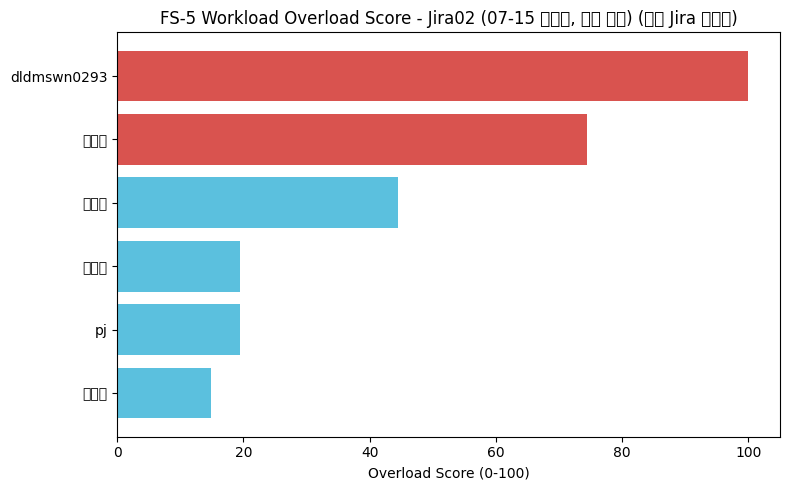

In [13]:
os.makedirs("output", exist_ok=True)

main_label = "Jira02 (07-15 스냅샷, 최다 업무)"
main_result = jira_results[main_label]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#d9534f" if a else "#5bc0de" for a in main_result["is_anomaly"]]
ax.barh(main_result["assignee_id"], main_result["overload_score_0_100"], color=colors)
ax.set_xlabel("Overload Score (0-100)")
ax.set_title(f"FS-5 Workload Overload Score - {main_label} (실제 Jira 데이터)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("output/overload_score_jira_real_data.png", dpi=150)
plt.show()


### 7-2. Supabase 실 데이터 연결

`App/backend_fastapi/.env`에 `DATABASE_URL`이 설정돼 있어야 연결된다. 아직 없거나 연결에 실패하면
예외를 잡아 메시지만 출력하고 넘어간다(노트북 전체가 죽지 않도록). 연결에 성공하면 실제
`category`/`priority` 값이 운영 코드의 `CATEGORY_WEIGHT`/`PRIORITY_WEIGHT` 키와 실제로 일치하는지도
같이 확인한다 — 안 맞는 값은 조용히 가중치 0(또는 기본값)으로 처리되기 때문에 반드시 짚어야 하는 부분이다.

In [14]:
from dotenv import load_dotenv

# workload_db.py의 dotenv_values()는 인자 없이 호출되면 python-dotenv의 find_dotenv()가
# 대신 검색을 시도하는데, Jupyter 커널에서는 __main__에 __file__이 없어(대화형으로 판단)
# 항상 os.getcwd()(=이 노트북 위치)부터 검색한다. document_이은주/는 .env가 있는
# App/backend_fastapi/ 또는 App/의 조상 디렉터리가 아니므로 못 찾는다 — 그래서 여기서
# 노트북 전용으로 명시적 경로를 먼저 로드해준다(운영 코드는 uvicorn으로 실행되면
# 정상적으로 자기 파일 위치 기준 상위 탐색이 되므로 수정할 필요 없음).
for _candidate in (BACKEND_FASTAPI_PATH / ".env", BACKEND_FASTAPI_PATH.parent / ".env"):
    if _candidate.exists():
        load_dotenv(_candidate, override=True)
        print(f".env 로드됨: {_candidate}")
        break
else:
    print(".env를 찾지 못함 (App/backend_fastapi/.env 또는 App/.env 확인 필요)")

from ml_workload_score.app.services import workload_db as db
from ml_workload_score.app.services.workload_model import normalize_category, normalize_priority

SUPABASE_PROJECT_ID = 1  # 실제 project_id 확인되면 교체

supabase_result = None
try:
    supabase_tasks_df = db.load_tasks_from_db(project_id=SUPABASE_PROJECT_ID)
    print(f"Supabase 연결 성공 — project_id={SUPABASE_PROJECT_ID}, 조회된 업무 {len(supabase_tasks_df)}건")

    if supabase_tasks_df.empty:
        print("배정된 업무가 없어(0건) 편중 점수 계산 대상 없음 "
              "— get_workload_score()의 기존 빈 응답 처리 로직과 일치하는 정상 케이스.")
    else:
        real_categories = set(supabase_tasks_df["category"].dropna().unique())
        real_priorities = set(supabase_tasks_df["priority"].dropna().unique())
        print("실제 category distinct 값:", sorted(real_categories))
        print("실제 priority distinct 값:", sorted(real_priorities))

        # CATEGORY_ALIASES/PRIORITY_ALIASES(workload_model.py)로 정규화한 뒤에도
        # 여전히 CATEGORY_WEIGHT/PRIORITY_WEIGHT에 없는 값만 진짜 미매핑이다.
        still_unmapped_categories = {c for c in real_categories if normalize_category(c) not in CATEGORY_WEIGHT}
        still_unmapped_priorities = {p for p in real_priorities if normalize_priority(p) not in PRIORITY_WEIGHT}
        if still_unmapped_categories:
            print("⚠ 별칭 매핑 후에도 미매핑인 category 값 (가중치 0으로 처리됨):", still_unmapped_categories)
        else:
            print("✅ 실제 category 값 전부 CATEGORY_ALIASES로 정규화 확인됨")
        if still_unmapped_priorities:
            print("⚠ 별칭 매핑 후에도 미매핑인 priority 값 (기본값 2로 처리됨):", still_unmapped_priorities)
        else:
            print("✅ 실제 priority 값 전부 PRIORITY_ALIASES로 정규화 확인됨")

        supabase_features = build_features(supabase_tasks_df)
        supabase_result = detect_overload_anomalies_auto(supabase_features)
        print(f"\n사용된 방법: {supabase_result.attrs.get('method_used')}")
        display(supabase_result[["assignee_id", "task_count_total", "completion_rate",
                                  "overload_score_0_100", "is_anomaly", "anomaly_type"]])
except Exception as e:
    print(f"Supabase 연결 실패 (App/backend_fastapi/.env 또는 App/.env의 DATABASE_URL 확인 필요): {e}")


.env 로드됨: C:\AI-projects\work-flow\App\.env


Supabase 연결 성공 — project_id=1, 조회된 업무 17건
실제 category distinct 값: ['QA', 'ai-ml', 'backend', 'devops', 'frontend', 'other']
실제 priority distinct 값: ['HIGH', 'MEDIUM', 'high', 'medium']
✅ 실제 category 값 전부 CATEGORY_ALIASES로 정규화 확인됨
✅ 실제 priority 값 전부 PRIORITY_ALIASES로 정규화 확인됨

사용된 방법: MAD (소규모 팀)


,assignee_id,task_count_total,completion_rate,overload_score_0_100,is_anomaly,anomaly_type
2,3,3,0.0,100.000000,True,이상 패턴(방향 불명확)
0,1,7,0.0,12.647986,False,정상
3,4,2,0.0,9.427252,False,정상
1,2,5,0.0,6.798088,False,정상


### 7-3. 합성 vs Jira vs Supabase 비교

In [15]:
comparison_rows = [{
    "데이터셋": "합성 데이터 (2장)",
    "팀원 수": len(features),
    "사용된 방법": result.attrs.get("method_used"),
    "이상치 탐지 수": int(result["is_anomaly"].sum()),
}]

for label, r in jira_results.items():
    comparison_rows.append({
        "데이터셋": label,
        "팀원 수": len(r),
        "사용된 방법": r.attrs.get("method_used"),
        "이상치 탐지 수": int(r["is_anomaly"].sum()),
    })

if supabase_result is not None:
    comparison_rows.append({
        "데이터셋": f"Supabase 실 데이터 (project_id={SUPABASE_PROJECT_ID})",
        "팀원 수": len(supabase_result),
        "사용된 방법": supabase_result.attrs.get("method_used"),
        "이상치 탐지 수": int(supabase_result["is_anomaly"].sum()),
    })
else:
    print("Supabase 데이터는 연결되지 않아 비교표에서 제외함 (.env 준비 후 재실행하면 자동 포함됨).")

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,데이터셋,팀원 수,사용된 방법,이상치 탐지 수
0,합성 데이터 (2장),7,MAD (소규모 팀),1
1,Jira01 (07-14 스냅샷),6,MAD (소규모 팀),2
2,"Jira02 (07-15 스냅샷, 최다 업무)",6,MAD (소규모 팀),2
3,Jira03 (07-15 스냅샷),6,MAD (소규모 팀),2
4,Supabase 실 데이터 (project_id=1),4,MAD (소규모 팀),1
